In [13]:
%load_ext autoreload
%autoreload 2

import numpy as np
import os
import time
import pickle
import matplotlib.pyplot as plt
from scipy.stats import norm
from matplotlib.ticker import MaxNLocator

from f_compare_bn import *

# global var
S0 = 1.0
K = 1.0
r = 0.03
sigma = np.sqrt(0.05)
T = 1.5
BS_eta = (S0, K, r, sigma, T)
# S0, K, r, kappa, theta, xi, rho, Y0, T = Hes_eta
Hes_eta = (S0, K, r, 2, 0.05, 0.5, -0.7, 0.05, T)

B = 0.8 # down-and-out must B < S0 and B < K
opt_type = 'call' # call or put
barr_type = 'van' # van or barr
model_type = 'bs' # hes or bs
chunk_dir = f"/mnt/d/bs_chunks_correction/" if model_type == 'bs' else f"/mnt/d/hes_chunks_correction/"

if not((B < S0) & (B < K)):
    raise ValueError("down-and-out : B should be smaller than S0 and K")

if not(opt_type == 'call' or  opt_type == 'put'):
    raise ValueError("option_type must be 'call' or 'put'")

if not(barr_type == 'van' or  barr_type == 'barr'):
    raise ValueError("barr_type must be 'van' or 'barr'")

if not(model_type == 'hes' or  model_type == 'bs'):
    raise ValueError("model_type must be 'hes' or 'bs'")

if not(torch.cuda.is_available()):
    raise ValueError("CUDA is not available")
device = torch.device("cuda")

if model_type == 'hes':
    if barr_type == 'barr':
        if opt_type == 'call':
            bench_price = 0.115733
        else: # put
            bench_price = 0.005170
    else: # van
        if opt_type == 'call':
            bench_price = 0.124491
        else: # put
            bench_price = 0.080488

elif model_type == 'bs':
    if barr_type == 'barr':
        if opt_type == 'call':
            bench_price = 0.123493
        else: # put
            bench_price = 0.009535
    else: # van
        if opt_type == 'call':
            bench_price = 0.129944
        else: # put
            bench_price = 0.085942

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# CVAE settings
dim_z       = 8 # 12
hidden_dims = [128, 128, 64] # [128, 128, 64], [256, 256, 128], [512, 512, 256]
batch_size  = 4096 # 1024, 2048, 4096, 8192
lr          = 1e-3 # 3e-4, 5e-4
beta        = 1.0
use_bn = False
num_chunks = 5
save_path = f"cvae_{model_type}_{barr_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_chunk5_NBN.pt"
load_path = None # 과거 weight를 저장하지 않았던 모델에 적용하기 위한 변수
resume_path = None # 이어서 학습하고 싶을 때


n_samples = 10000 # n_samples= 1k, 10k, 100k
if n_samples % 2 != 0:
    raise ValueError("n_samples should be an even number for antithetic sampling")

if model_type == 'hes':
    test_etas = [0.03, 2.0,  0.05, 0.5, -0.7, 0.05, 1.5]
    eta_keys  = ['r', 'lambda', 'v_bar', 'xi', 'rho', 'Y0', 'T']
else: # model_type = 'bs'
    test_etas = [r, sigma, T]
    eta_keys  = ['r', 'sigma', 'T']

# Loss history

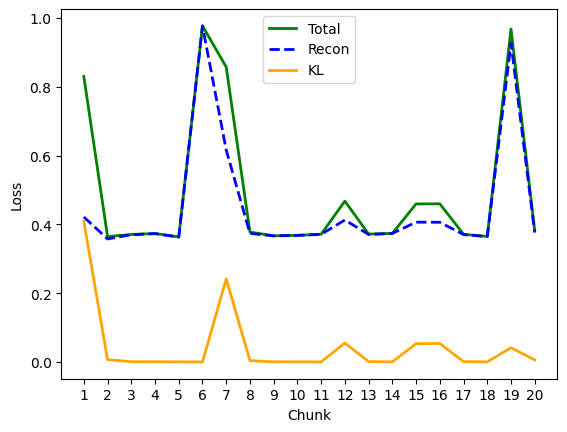

In [ ]:
save_path = f"cvae_{model_type}_{barr_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_chunk20_NBN.pt"
ckpt = torch.load(save_path, map_location=device, weights_only=False)
chunk_loss_history = ckpt.get("chunk_loss_history", None)

chunks = range(1, len(chunk_loss_history["total_loss"]) + 1)
plt.plot(chunks, chunk_loss_history["total_loss"], label="Total", color="green", linewidth=2)
plt.plot(chunks, chunk_loss_history["recon_loss"], label="Recon", color="blue", linestyle="--", linewidth=2)
plt.plot(chunks, chunk_loss_history["KL_loss"], label="KL", color="orange", linewidth=2)
plt.xlabel('Chunk')
plt.ylabel('Loss')
plt.xticks(chunks)
#ax = plt.gca()
#ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.legend()
plt.show()

In [12]:
save_path = f"cvae_{model_type}_{barr_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_chunk20_NBN.pt"
ckpt = torch.load(save_path, map_location=device, weights_only=False)
chunk_loss_history = ckpt.get("chunk_loss_history", None)

for i in range(len(chunk_loss_history["total_loss"])):
    print(f"Total Loss: {chunk_loss_history['total_loss'][i]:.4f}, Recon Loss: {chunk_loss_history['recon_loss'][i]:.4f}, KL Loss: {chunk_loss_history['KL_loss'][i]:.4f}")

Total Loss: 0.8298, Recon Loss: 0.4213, KL Loss: 0.4085
Total Loss: 0.3644, Recon Loss: 0.3576, KL Loss: 0.0068
Total Loss: 0.3705, Recon Loss: 0.3698, KL Loss: 0.0007
Total Loss: 0.3733, Recon Loss: 0.3728, KL Loss: 0.0005
Total Loss: 0.3633, Recon Loss: 0.3630, KL Loss: 0.0003
Total Loss: 0.9768, Recon Loss: 0.9767, KL Loss: 0.0000
Total Loss: 0.8573, Recon Loss: 0.6162, KL Loss: 0.2412
Total Loss: 0.3775, Recon Loss: 0.3736, KL Loss: 0.0039
Total Loss: 0.3667, Recon Loss: 0.3664, KL Loss: 0.0003
Total Loss: 0.3680, Recon Loss: 0.3678, KL Loss: 0.0002
Total Loss: 0.3711, Recon Loss: 0.3709, KL Loss: 0.0002
Total Loss: 0.4675, Recon Loss: 0.4126, KL Loss: 0.0549
Total Loss: 0.3717, Recon Loss: 0.3706, KL Loss: 0.0010
Total Loss: 0.3737, Recon Loss: 0.3735, KL Loss: 0.0002
Total Loss: 0.4593, Recon Loss: 0.4063, KL Loss: 0.0530
Total Loss: 0.4596, Recon Loss: 0.4060, KL Loss: 0.0536
Total Loss: 0.3711, Recon Loss: 0.3702, KL Loss: 0.0009
Total Loss: 0.3647, Recon Loss: 0.3643, KL Loss:

# compare distribution of X_T and M_T

In [16]:
num_chunks = 100
bins = 100

In [ ]:
real_result = show_real_chunk_results(
    chunk_dir,
    num_chunks,
    bins=bins,
    x_range=None, # graph range
    m_range=None,
)

real_x_stats = real_result["real_x_stats"]
real_m_stats = real_result["real_m_stats"]
n_samples = real_result["n_samples"]

Using real data from 100/100 chunks
first chunk: bs_chunk_000.h5
last chunk : bs_chunk_099.h5


In [ ]:
# use BN
bn_result = show_cvae_sample_results(
    name="CVAE BN",
    save_path=f"cvae_{model_type}_{barr_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_chunk100_BN.pt",
    test_etas=test_etas,
    n_samples=n_samples,
    bins=bins,
)

x_bn = bn_result["x"]
m_bn = bn_result["m"]
ckpt_bn = bn_result["ckpt"]

In [ ]:
# not use BN
no_bn_result = show_cvae_sample_results(
    name="CVAE no BN",
    save_path=f"cvae_{model_type}_{barr_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_chunk100_NBN.pt",
    test_etas=test_etas,
    n_samples=n_samples,
    bins=bins,
)

x_no_bn = no_bn_result["x"]
m_no_bn = no_bn_result["m"]
ckpt_no_bn = no_bn_result["ckpt"]

In [ ]:
plot_three_distributions(x_no_bn, x_no_bn, x_bn, name="X_T", bins=bins)

In [ ]:
real_price = vanilla_price_from_xt(real_x, K, r, T, opt_type)
no_bn_price = vanilla_price_from_xt(x_no_bn, K, r, T, opt_type)
bn_price = vanilla_price_from_xt(x_bn, K, r, T, opt_type)

print("Real vanilla price:", real_price)
print("No BN price       :", no_bn_price, f"error={price_error(no_bn_price, real_price):+.2f}%")
print("BN price          :", bn_price, f"error={price_error(bn_price, real_price):+.2f}%")

In [ ]:
real_price = barrier_price_from_xt_mt(real_x, real_m, K, r, T, opt_type, B=B)
no_bn_price = barrier_price_from_xt_mt(x_no_bn, m_no_bn, K, r, T, opt_type, B=B)
bn_price = barrier_price_from_xt_mt(x_bn, m_bn, K, r, T, opt_type, B=B)

# inference for comparing with MC result

In [8]:
cvae_save_path = f"cvae_{model_type}_{barr_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_chunk20_BN.pt" # = save_path

cvae_result_path = f"cvae_{model_type}_{barr_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_chunk20_BN.pkl"

ckpt = torch.load(cvae_save_path, map_location=device, weights_only=False)

cvae = CVAE(
    dim_x=ckpt["dim_x"],
    dim_eta=ckpt["dim_eta"],
    dim_z=ckpt["dim_z"],
    hidden_dims=ckpt["hidden_dims"],
    use_bn=ckpt.get("use_bn", False),
).to(device)

state_dict = ckpt["model_state"]
if any(k.startswith("module.") for k in state_dict):
    state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

cvae.load_state_dict(state_dict)
cvae.eval()

eta_raw = np.array(test_etas, dtype=np.float32)
eta_scaled = (eta_raw - ckpt["eta_min"]) / (ckpt["eta_max"] - ckpt["eta_min"] + 1e-8)
eta_t = torch.tensor(eta_scaled, dtype=torch.float32, device=device)

n_list = [1000, 10000, 100000]
n_repeats = 50
results = {n: [] for n in n_list}


for n in n_list:
    for _ in range(n_repeats):
        if barr_type == "barr":
            price = cvae.price_barrier(eta_t, B, K, r, T, opt_type, n)
        else:
            price = cvae.price_vanilla(eta_t, K, r, T, opt_type, n)
        results[n].append(price)

with open(cvae_result_path, "wb") as f:
    pickle.dump(results, f)

CVAE
n=  1000 | mean=0.12759796 | 95% CI=±0.01170354 | error=-1.81%
n= 10000 | mean=0.12775664 | 95% CI=±0.00383148 | error=-1.68%
n=100000 | mean=0.12800448 | 95% CI=±0.00120472 | error=-1.49%


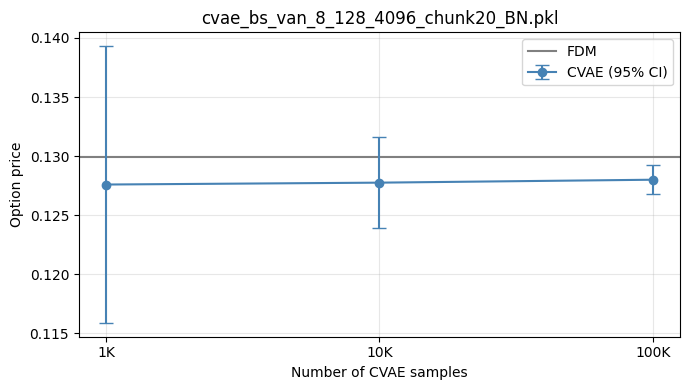

In [9]:
# 공용 그래프: CVAE inference 결과만 표시
n_list = [1000, 10000, 100000]
cvae_result_path = f"cvae_{model_type}_{barr_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_chunk20_BN.pkl"

with open(cvae_result_path, "rb") as f:
    results = pickle.load(f)

means = np.array([np.mean(results[n]) for n in n_list])
stds = np.array([np.std(results[n]) for n in n_list])
ci = 1.96 * stds

print("CVAE")
for n, mean, err in zip(n_list, means, ci):
    rel_err = (mean - bench_price) / (bench_price + 1e-12) * 100
    print(f"n={n:6d} | mean={mean:.8f} | 95% CI=±{err:.8f} | error={rel_err:+.2f}%")

plt.figure(figsize=(7, 4))
plt.axhline(bench_price, color="gray", linewidth=1.5, label="FDM")
plt.errorbar(
    range(len(n_list)), means,
    yerr=ci, fmt="o-", color="steelblue", capsize=5, label="CVAE (95% CI)",
)
plt.xticks(range(len(n_list)), ["1K", "10K", "100K"])
plt.xlabel("Number of CVAE samples")
plt.ylabel("Option price")
plt.title(f"{cvae_result_path}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
